### Import Dependencies

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import f1_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from scipy.special import expit
import numpy as np
import pandas as pd
import pickle
from sklearn.utils import resample
from strategies import *
from collections import Counter
import random
import matplotlib.pyplot as plt

### Import Data

In [4]:
data = pd.read_pickle('mimic3_data_test.pkl')

### Define the main loop and simulation runs

#### Define the active learning loop and simulation loops

In [ ]:
def active_learning_loop(data, data_size, initial_size, batch_size, n_iterations, method='diversity sampling', seed=42):

    # === Step 1 ===
    all_labels = [code for label_list in data['ICD9_CODE'] for code in label_list]
    top_labels = set([label for label, _ in Counter(all_labels).most_common(100)])
    data['filtered_labels'] = data['ICD9_CODE'].apply(lambda codes: [c for c in codes if c in top_labels])
    data = data[data['filtered_labels'].map(len) > 0]

    texts = data['TEXT'].tolist()
    labels = data['filtered_labels'].tolist()
    X_pool, X_val, y_pool, y_val = train_test_split(texts, labels, test_size=0.2, random_state=seed)
    X_pool, y_pool = X_pool[:data_size], y_pool[:data_size]

    indices = np.arange(len(X_pool))
    np.random.seed(seed)
    np.random.shuffle(indices)
    X_pool = [X_pool[i] for i in indices]
    y_pool = [y_pool[i] for i in indices]

    # === Step 2 ===
    X_labeled = X_pool[:initial_size]
    y_labeled = y_pool[:initial_size]
    X_unlabeled = X_pool[initial_size:]
    y_unlabeled = y_pool[initial_size:]

    # === Step 3 ===
    vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
    mlb = MultiLabelBinarizer()
    vectorizer.fit(X_pool + X_val)
    micro_f1_list, macro_f1_list, mse_list = [], [], []

    # === Step 4 ===
    for i in range(1,n_iterations+1):
        print(f"\n--- Iter {i}/{n_iterations} | Labeled size = {len(X_labeled)} ---")

        X_vec = vectorizer.transform(X_labeled)
        Y_bin = mlb.fit_transform(y_labeled)
        clf = OneVsRestClassifier(
            SGDClassifier(loss='log_loss', class_weight='balanced', alpha=1.0, max_iter=3000, tol=1e-4, random_state=42),
            n_jobs=-1
        )
        clf.fit(X_vec, Y_bin)

        X_val_vec = vectorizer.transform(X_val)
        Y_val_bin = mlb.transform(y_val)
        Y_val_score = clf.decision_function(X_val_vec)
        Y_val_prob = expit(Y_val_score)
        Y_val_pred = (Y_val_prob >= 0.5).astype(int)
        micro_f1 = f1_score(Y_val_bin, Y_val_pred, average='micro')
        macro_f1 = f1_score(Y_val_bin, Y_val_pred, average='macro')
        mse = mean_squared_error(Y_val_bin, Y_val_pred)
        micro_f1_list.append(micro_f1)
        macro_f1_list.append(macro_f1)
        mse_list.append(mse)
        print(f"Micro-F1: {micro_f1:.4f} | Macro-F1: {macro_f1:.4f} | MSE: {mse:.4f}")

        # === Data selection ===
        if len(X_unlabeled) < batch_size:
            print("Unlabeled pool exhausted.")
            break

        selected_idx = []
        X_unlabeled_vec = vectorizer.transform(X_unlabeled).toarray()

        if method == 'diversity sampling':
            selected_idx = diversity_sampling_kmeans(
                embeddings=X_unlabeled_vec,
                batch_size=batch_size,
                n_clusters=batch_size,
                mode='centroid'
            )
        elif method == 'uncertainty sampling':
            probs = clf.predict_proba(X_unlabeled_vec)
            selected_idx = uncertainty_sampling(
                probabilities=probs,
                batch_size=batch_size,
                mode='least_confidence'
            )

        elif method == 'information density':
            selected_idx = information_density_sampling(
                embeddings=X_unlabeled_vec,
                batch_size=batch_size,
                n_components=100
            )

        else:
            raise ValueError(f"Unknown method: {method}")

        # === Update the labeled pool ===
        for idx in sorted(selected_idx, reverse=True):
            X_labeled.append(X_unlabeled.pop(idx))
            y_labeled.append(y_unlabeled.pop(idx))

    return micro_f1_list, macro_f1_list, mse_list


In [ ]:
def run_simulations(data, seeds, data_size=1000, initial_size=100, batch_size=10, n_iterations=10, method='diversity sampling'):
    all_micro_f1 = []
    all_macro_f1 = []
    all_mse = []

    for run_id, seed in enumerate(seeds):
        print(f"===== Simulation {run_id + 1} | Seed = {seed} =====")

        random.seed(seed)
        np.random.seed(seed)

        micro_f1, macro_f1, mse = active_learning_loop(
            data=data,
            data_size=data_size,
            initial_size=initial_size,
            batch_size=batch_size,
            n_iterations=n_iterations,
            method=method,
            seed=seed
        )

        all_micro_f1.append(micro_f1)
        all_macro_f1.append(macro_f1)
        all_mse.append(mse)

    return all_micro_f1, all_macro_f1, all_mse


#### Define the passive learning main loop and simulation runs

In [ ]:
def random_sampling_loop(data, data_size=1000, initial_size=100, batch_size=100, n_iterations=10):

    # === Step 1 ===
    all_labels = [code for label_list in data['ICD9_CODE'] for code in label_list]
    top_labels = set([label for label, _ in Counter(all_labels).most_common(100)])
    data['filtered_labels'] = data['ICD9_CODE'].apply(lambda codes: [c for c in codes if c in top_labels])
    data = data[data['filtered_labels'].map(len) > 0]

    # === Step 2 ===
    texts = data['TEXT'].tolist()
    labels = data['filtered_labels'].tolist()
    X_pool, X_val, y_pool, y_val = train_test_split(texts, labels, test_size=0.2, random_state=42)

    X_pool = X_pool[:data_size]
    y_pool = y_pool[:data_size]

    # === Step 3 ===
    X_labeled = X_pool[:initial_size]
    y_labeled = y_pool[:initial_size]
    X_unlabeled = X_pool[initial_size:]
    y_unlabeled = y_pool[initial_size:]

    # === Step 4 ===
    vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
    mlb = MultiLabelBinarizer()
    vectorizer.fit(X_pool + X_val)
    micro_f1_list = []
    macro_f1_list = []
    mse_list = []

    for i in range(1,n_iterations+1):
        print(f"Iter {i}/{n_iterations} | Labeled size: {len(X_labeled)}")

        X_vec = vectorizer.transform(X_labeled)
        Y_bin = mlb.fit_transform(y_labeled)
        clf = OneVsRestClassifier(
            SGDClassifier(loss='log_loss', alpha=1.0, max_iter=3000, tol=1e-4, class_weight='balanced', random_state=42),
            n_jobs=1
        )
        clf.fit(X_vec, Y_bin)

        X_val_vec = vectorizer.transform(X_val)
        Y_val_bin = mlb.transform(y_val)
        Y_val_score = clf.decision_function(X_val_vec)
        Y_val_prob = expit(Y_val_score)
        Y_val_pred = (Y_val_prob >= 0.5).astype(int)

        micro = f1_score(Y_val_bin, Y_val_pred, average='micro')
        macro = f1_score(Y_val_bin, Y_val_pred, average='macro')
        mse = mean_squared_error(Y_val_bin, Y_val_pred)

        micro_f1_list.append(micro)
        macro_f1_list.append(macro)
        mse_list.append(mse)
        print(f"Micro-F1: {micro:.4f} | Macro-F1: {macro:.4f} | Mse: {mse:.4f}\n")

        if len(X_unlabeled) < batch_size:
            print("Not enough unlabeled data left. Stopping.")
            break

        selected_idx = random.sample(range(len(X_unlabeled)), batch_size)

        for idx in sorted(selected_idx, reverse=True):
            X_labeled.append(X_unlabeled.pop(idx))
            y_labeled.append(y_unlabeled.pop(idx))

    return micro_f1_list, macro_f1_list, mse_list


In [ ]:
def run_passive_simulations(data, seeds, data_size=1000, initial_size=100, batch_size=10, n_iterations=10):
    all_micro_f1 = []
    all_macro_f1 = []
    all_mse = []

    for run_id, seed in enumerate(seeds):
        print(f"===== Simulation {run_id + 1} | Seed = {seed} =====")

        random.seed(seed)
        np.random.seed(seed)

        micro_f1, macro_f1, mse = random_sampling_loop(
            data=data,
            data_size=data_size,
            initial_size=initial_size,
            batch_size=batch_size,
            n_iterations=n_iterations
        )

        all_micro_f1.append(micro_f1)
        all_macro_f1.append(macro_f1)
        all_mse.append(mse)

    return all_micro_f1, all_macro_f1, all_mse


### Data size = 1000

#### Run experiments

In [ ]:
seeds = [36, 17, 88, 1234, 2025]

di1000_micro_results, di1000_macro_results, di1000_mse_results = run_simulations(
    data=data,
    seeds=seeds,
    data_size=1000,
    initial_size=100,
    batch_size=100,
    n_iterations=10,
    method='diversity sampling'
)

===== Simulation 1 | Seed = 36 =====

--- Iter 1/10 | Labeled size = 100 ---


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['27800', '4111', 'E8788', 'V4986'] will be ignored
  warnings.warn(


Micro-F1: 0.1516 | Macro-F1: 0.1366 | MSE: 0.3934

--- Iter 2/10 | Labeled size = 200 ---
Micro-F1: 0.1447 | Macro-F1: 0.1509 | MSE: 0.5357

--- Iter 3/10 | Labeled size = 300 ---
Micro-F1: 0.1596 | Macro-F1: 0.1408 | MSE: 0.4024

--- Iter 4/10 | Labeled size = 400 ---
Micro-F1: 0.1402 | Macro-F1: 0.1335 | MSE: 0.4420

--- Iter 5/10 | Labeled size = 500 ---
Micro-F1: 0.1457 | Macro-F1: 0.1199 | MSE: 0.3845

--- Iter 6/10 | Labeled size = 600 ---
Micro-F1: 0.1420 | Macro-F1: 0.1436 | MSE: 0.4533

--- Iter 7/10 | Labeled size = 700 ---
Micro-F1: 0.1357 | Macro-F1: 0.1282 | MSE: 0.3676

--- Iter 8/10 | Labeled size = 800 ---
Micro-F1: 0.1538 | Macro-F1: 0.1321 | MSE: 0.3797

--- Iter 9/10 | Labeled size = 900 ---
Micro-F1: 0.1526 | Macro-F1: 0.1187 | MSE: 0.3402

--- Iter 10/10 | Labeled size = 1000 ---
Micro-F1: 0.1389 | Macro-F1: 0.1367 | MSE: 0.5164
Unlabeled pool exhausted.
===== Simulation 2 | Seed = 17 =====

--- Iter 1/10 | Labeled size = 100 ---


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['5715', '99591', 'E8782'] will be ignored
  warnings.warn(


Micro-F1: 0.1375 | Macro-F1: 0.1174 | MSE: 0.4112

--- Iter 2/10 | Labeled size = 200 ---
Micro-F1: 0.1486 | Macro-F1: 0.1484 | MSE: 0.4686

--- Iter 3/10 | Labeled size = 300 ---
Micro-F1: 0.1302 | Macro-F1: 0.1102 | MSE: 0.3328

--- Iter 4/10 | Labeled size = 400 ---
Micro-F1: 0.1482 | Macro-F1: 0.1432 | MSE: 0.3746

--- Iter 5/10 | Labeled size = 500 ---
Micro-F1: 0.1350 | Macro-F1: 0.1327 | MSE: 0.4734

--- Iter 6/10 | Labeled size = 600 ---
Micro-F1: 0.1516 | Macro-F1: 0.1356 | MSE: 0.3351

--- Iter 7/10 | Labeled size = 700 ---
Micro-F1: 0.1474 | Macro-F1: 0.1425 | MSE: 0.3460

--- Iter 8/10 | Labeled size = 800 ---
Micro-F1: 0.1404 | Macro-F1: 0.1309 | MSE: 0.3115

--- Iter 9/10 | Labeled size = 900 ---
Micro-F1: 0.1421 | Macro-F1: 0.1369 | MSE: 0.3066

--- Iter 10/10 | Labeled size = 1000 ---
Micro-F1: 0.1423 | Macro-F1: 0.1392 | MSE: 0.3412
Unlabeled pool exhausted.
===== Simulation 3 | Seed = 88 =====

--- Iter 1/10 | Labeled size = 100 ---


...

Micro-F1: 0.1454 | Macro-F1: 0.1314 | MSE: 0.4144

--- Iter 3/10 | Labeled size = 300 ---
Micro-F1: 0.1437 | Macro-F1: 0.1143 | MSE: 0.4017

--- Iter 4/10 | Labeled size = 400 ---
Micro-F1: 0.1352 | Macro-F1: 0.1179 | MSE: 0.3597

--- Iter 5/10 | Labeled size = 500 ---
Micro-F1: 0.1616 | Macro-F1: 0.1461 | MSE: 0.3392

--- Iter 6/10 | Labeled size = 600 ---
Micro-F1: 0.1497 | Macro-F1: 0.1302 | MSE: 0.3465

--- Iter 7/10 | Labeled size = 700 ---
Micro-F1: 0.1347 | Macro-F1: 0.1353 | MSE: 0.3915

--- Iter 8/10 | Labeled size = 800 ---
Micro-F1: 0.1253 | Macro-F1: 0.1398 | MSE: 0.3600

--- Iter 9/10 | Labeled size = 900 ---
Micro-F1: 0.1541 | Macro-F1: 0.1280 | MSE: 0.2878

--- Iter 10/10 | Labeled size = 1000 ---
Micro-F1: 0.1568 | Macro-F1: 0.1336 | MSE: 0.3180
Unlabeled pool exhausted.
===== Simulation 4 | Seed = 1234 =====

--- Iter 1/10 | Labeled size = 100 ---


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['30000', '5715'] will be ignored
  warnings.warn(


Micro-F1: 0.1621 | Macro-F1: 0.1254 | MSE: 0.3383

--- Iter 2/10 | Labeled size = 200 ---
Micro-F1: 0.1355 | Macro-F1: 0.1277 | MSE: 0.4191

--- Iter 3/10 | Labeled size = 300 ---
Micro-F1: 0.1452 | Macro-F1: 0.1213 | MSE: 0.3602

--- Iter 4/10 | Labeled size = 400 ---
Micro-F1: 0.1490 | Macro-F1: 0.1338 | MSE: 0.4245

--- Iter 5/10 | Labeled size = 500 ---
Micro-F1: 0.1475 | Macro-F1: 0.1544 | MSE: 0.3976

--- Iter 6/10 | Labeled size = 600 ---
Micro-F1: 0.1425 | Macro-F1: 0.1566 | MSE: 0.4486

--- Iter 7/10 | Labeled size = 700 ---
Micro-F1: 0.1621 | Macro-F1: 0.1434 | MSE: 0.3482

--- Iter 8/10 | Labeled size = 800 ---
Micro-F1: 0.1522 | Macro-F1: 0.1418 | MSE: 0.4566

--- Iter 9/10 | Labeled size = 900 ---
Micro-F1: 0.1579 | Macro-F1: 0.1207 | MSE: 0.2910

--- Iter 10/10 | Labeled size = 1000 ---
Micro-F1: 0.1497 | Macro-F1: 0.1137 | MSE: 0.3462
Unlabeled pool exhausted.
===== Simulation 5 | Seed = 2025 =====

--- Iter 1/10 | Labeled size = 100 ---


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['30000', '4254', 'E8782', 'E8798'] will be ignored
  warnings.warn(


Micro-F1: 0.1402 | Macro-F1: 0.1438 | MSE: 0.4444

--- Iter 2/10 | Labeled size = 200 ---
Micro-F1: 0.1540 | Macro-F1: 0.1503 | MSE: 0.4090

--- Iter 3/10 | Labeled size = 300 ---
Micro-F1: 0.1526 | Macro-F1: 0.1604 | MSE: 0.4119

--- Iter 4/10 | Labeled size = 400 ---
Micro-F1: 0.1635 | Macro-F1: 0.1615 | MSE: 0.3802

--- Iter 5/10 | Labeled size = 500 ---
Micro-F1: 0.1674 | Macro-F1: 0.1664 | MSE: 0.3808

--- Iter 6/10 | Labeled size = 600 ---
Micro-F1: 0.1321 | Macro-F1: 0.1460 | MSE: 0.4882

--- Iter 7/10 | Labeled size = 700 ---
Micro-F1: 0.1552 | Macro-F1: 0.1302 | MSE: 0.4033

--- Iter 8/10 | Labeled size = 800 ---
Micro-F1: 0.1644 | Macro-F1: 0.1437 | MSE: 0.3050

--- Iter 9/10 | Labeled size = 900 ---
Micro-F1: 0.1459 | Macro-F1: 0.1254 | MSE: 0.3247

--- Iter 10/10 | Labeled size = 1000 ---
Micro-F1: 0.1432 | Macro-F1: 0.1485 | MSE: 0.4628
Unlabeled pool exhausted.


In [ ]:
un1000_micro_results, un1000_macro_results, un1000_mse_results = run_simulations(
    data=data,
    seeds=seeds,
    data_size=1000,
    initial_size=100,
    batch_size=100,
    n_iterations=10,
    method='uncertainty sampling'
)

In [ ]:
info1000_micro_results, info1000_macro_results, info1000_mse_results = run_simulations(
    data=data,
    seeds=seeds,
    data_size=1000,
    initial_size=100,
    batch_size=100,
    n_iterations=10,
    method='information density'
)

In [ ]:
pa1000_micro_results, pa1000_macro_results, pa1000_mse_results = run_passive_simulations(
    data=data,
    seeds=seeds,
    data_size=1000,
    initial_size=100,
    batch_size=100,
    n_iterations=10
)

===== Simulation 1 | Seed = 36 =====
Iter 1/10 | Labeled size: 100


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['00845', '2765', '99811'] will be ignored
  warnings.warn(


Micro-F1: 0.1470 | Macro-F1: 0.1312 | Mse: 0.3470

Iter 2/10 | Labeled size: 200
Micro-F1: 0.1624 | Macro-F1: 0.1382 | Mse: 0.3101

Iter 3/10 | Labeled size: 300
Micro-F1: 0.1415 | Macro-F1: 0.1227 | Mse: 0.4384

Iter 4/10 | Labeled size: 400
Micro-F1: 0.1448 | Macro-F1: 0.1317 | Mse: 0.4437

Iter 5/10 | Labeled size: 500
Micro-F1: 0.1612 | Macro-F1: 0.1341 | Mse: 0.3837

Iter 6/10 | Labeled size: 600
Micro-F1: 0.1611 | Macro-F1: 0.1480 | Mse: 0.3018

Iter 7/10 | Labeled size: 700
Micro-F1: 0.1689 | Macro-F1: 0.1404 | Mse: 0.3358

Iter 8/10 | Labeled size: 800
Micro-F1: 0.1638 | Macro-F1: 0.1526 | Mse: 0.3963

Iter 9/10 | Labeled size: 900
Micro-F1: 0.1323 | Macro-F1: 0.1259 | Mse: 0.3427

Iter 10/10 | Labeled size: 1000
Micro-F1: 0.1521 | Macro-F1: 0.1305 | Mse: 0.3980

Not enough unlabeled data left. Stopping.
===== Simulation 2 | Seed = 17 =====
Iter 1/10 | Labeled size: 100


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['00845', '2765', '99811'] will be ignored
  warnings.warn(


Micro-F1: 0.1470 | Macro-F1: 0.1312 | Mse: 0.3470

Iter 2/10 | Labeled size: 200
Micro-F1: 0.1610 | Macro-F1: 0.1409 | Mse: 0.3714

Iter 3/10 | Labeled size: 300
Micro-F1: 0.1620 | Macro-F1: 0.1471 | Mse: 0.3904

Iter 4/10 | Labeled size: 400
Micro-F1: 0.1542 | Macro-F1: 0.1309 | Mse: 0.3078

Iter 5/10 | Labeled size: 500
Micro-F1: 0.1479 | Macro-F1: 0.1346 | Mse: 0.2836

Iter 6/10 | Labeled size: 600
Micro-F1: 0.1486 | Macro-F1: 0.1474 | Mse: 0.3453

Iter 7/10 | Labeled size: 700
Micro-F1: 0.1429 | Macro-F1: 0.1192 | Mse: 0.2701

Iter 8/10 | Labeled size: 800
Micro-F1: 0.1637 | Macro-F1: 0.1491 | Mse: 0.3711

Iter 9/10 | Labeled size: 900
Micro-F1: 0.1557 | Macro-F1: 0.1542 | Mse: 0.3967

Iter 10/10 | Labeled size: 1000
Micro-F1: 0.1374 | Macro-F1: 0.1347 | Mse: 0.3676

Not enough unlabeled data left. Stopping.
===== Simulation 3 | Seed = 88 =====
Iter 1/10 | Labeled size: 100


...

Micro-F1: 0.1470 | Macro-F1: 0.1312 | Mse: 0.3470

Iter 2/10 | Labeled size: 200
Micro-F1: 0.1409 | Macro-F1: 0.1365 | Mse: 0.4434

Iter 3/10 | Labeled size: 300
Micro-F1: 0.1585 | Macro-F1: 0.1481 | Mse: 0.4091

Iter 4/10 | Labeled size: 400
Micro-F1: 0.1619 | Macro-F1: 0.1481 | Mse: 0.3321

Iter 5/10 | Labeled size: 500
Micro-F1: 0.1681 | Macro-F1: 0.1332 | Mse: 0.2622

Iter 6/10 | Labeled size: 600
Micro-F1: 0.1524 | Macro-F1: 0.1556 | Mse: 0.3320

Iter 7/10 | Labeled size: 700
Micro-F1: 0.1333 | Macro-F1: 0.1270 | Mse: 0.3105

Iter 8/10 | Labeled size: 800
Micro-F1: 0.1494 | Macro-F1: 0.1382 | Mse: 0.3850

Iter 9/10 | Labeled size: 900
Micro-F1: 0.1153 | Macro-F1: 0.1159 | Mse: 0.2814

Iter 10/10 | Labeled size: 1000
Micro-F1: 0.1448 | Macro-F1: 0.1197 | Mse: 0.3193

Not enough unlabeled data left. Stopping.
===== Simulation 4 | Seed = 1234 =====
Iter 1/10 | Labeled size: 100


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['00845', '2765', '99811'] will be ignored
  warnings.warn(


Micro-F1: 0.1470 | Macro-F1: 0.1312 | Mse: 0.3470

Iter 2/10 | Labeled size: 200
Micro-F1: 0.1602 | Macro-F1: 0.1432 | Mse: 0.3396

Iter 3/10 | Labeled size: 300
Micro-F1: 0.1469 | Macro-F1: 0.1416 | Mse: 0.4512

Iter 4/10 | Labeled size: 400
Micro-F1: 0.1467 | Macro-F1: 0.1180 | Mse: 0.3713

Iter 5/10 | Labeled size: 500
Micro-F1: 0.1681 | Macro-F1: 0.1527 | Mse: 0.2965

Iter 6/10 | Labeled size: 600
Micro-F1: 0.1454 | Macro-F1: 0.1444 | Mse: 0.3823

Iter 7/10 | Labeled size: 700
Micro-F1: 0.1477 | Macro-F1: 0.1378 | Mse: 0.3936

Iter 8/10 | Labeled size: 800
Micro-F1: 0.1466 | Macro-F1: 0.1273 | Mse: 0.4336

Iter 9/10 | Labeled size: 900
Micro-F1: 0.1719 | Macro-F1: 0.1405 | Mse: 0.2918

Iter 10/10 | Labeled size: 1000
Micro-F1: 0.1581 | Macro-F1: 0.1472 | Mse: 0.3647

Not enough unlabeled data left. Stopping.
===== Simulation 5 | Seed = 2025 =====
Iter 1/10 | Labeled size: 100


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['00845', '2765', '99811'] will be ignored
  warnings.warn(


Micro-F1: 0.1470 | Macro-F1: 0.1312 | Mse: 0.3470

Iter 2/10 | Labeled size: 200
Micro-F1: 0.1538 | Macro-F1: 0.1354 | Mse: 0.3425

Iter 3/10 | Labeled size: 300
Micro-F1: 0.1545 | Macro-F1: 0.1338 | Mse: 0.3903

Iter 4/10 | Labeled size: 400
Micro-F1: 0.1507 | Macro-F1: 0.1470 | Mse: 0.3889

Iter 5/10 | Labeled size: 500
Micro-F1: 0.1512 | Macro-F1: 0.1504 | Mse: 0.3757

Iter 6/10 | Labeled size: 600
Micro-F1: 0.1446 | Macro-F1: 0.1448 | Mse: 0.4065

Iter 7/10 | Labeled size: 700
Micro-F1: 0.1330 | Macro-F1: 0.1201 | Mse: 0.3596

Iter 8/10 | Labeled size: 800
Micro-F1: 0.1486 | Macro-F1: 0.1360 | Mse: 0.4264

Iter 9/10 | Labeled size: 900
Micro-F1: 0.1634 | Macro-F1: 0.1511 | Mse: 0.3769

Iter 10/10 | Labeled size: 1000
Micro-F1: 0.1386 | Macro-F1: 0.1299 | Mse: 0.3511

Not enough unlabeled data left. Stopping.


#### Convert results

In [ ]:
# Convert to numpy arrays
di_micro = np.array(di1000_micro_results)
di_macro = np.array(di1000_macro_results)
di_mse = np.array(di1000_mse_results)

# Calculate means and standard deviations
di_micro_means = np.mean(di_micro, axis=0)
di_micro_stds = np.std(di_micro, axis=0)
di_macro_means = np.mean(di_macro, axis=0)
di_macro_stds = np.std(di_macro, axis=0)
di_mse_means = np.mean(di_mse, axis=0)
di_mse_stds = np.std(di_mse, axis=0)

In [ ]:
un_micro = np.array(un1000_micro_results)
un_macro = np.array(un1000_macro_results)
un_mse = np.array(un1000_mse_results)

un_micro_means = np.mean(un_micro, axis=0)
un_micro_stds = np.std(un_micro, axis=0)
un_macro_means = np.mean(un_macro, axis=0)
un_macro_stds = np.std(un_macro, axis=0)
un_mse_means = np.mean(un_mse, axis=0)
un_mse_stds = np.std(un_mse, axis=0)

In [ ]:
info_micro = np.array(info1000_micro_results)
info_macro = np.array(info1000_macro_results)
info_mse = np.array(info1000_mse_results)

info_micro_means = np.mean(info_micro, axis=0)
info_micro_stds = np.std(info_micro, axis=0)
info_macro_means = np.mean(info_macro, axis=0)
info_macro_stds = np.std(info_macro, axis=0)
info_mse_means = np.mean(info_mse, axis=0)
info_mse_stds = np.std(info_mse, axis=0)

In [ ]:
pa_micro = np.array(pa1000_micro_results)
pa_macro = np.array(pa1000_macro_results)
pa_mse = np.array(pa1000_mse_results)

pa_micro_means = np.mean(pa_micro, axis=0)
pa_micro_stds = np.std(pa_micro, axis=0)
pa_macro_means = np.mean(pa_macro, axis=0)
pa_macro_stds = np.std(pa_macro, axis=0)
pa_mse_means = np.mean(pa_mse, axis=0)
pa_mse_stds = np.std(pa_mse, axis=0)

#### Plot

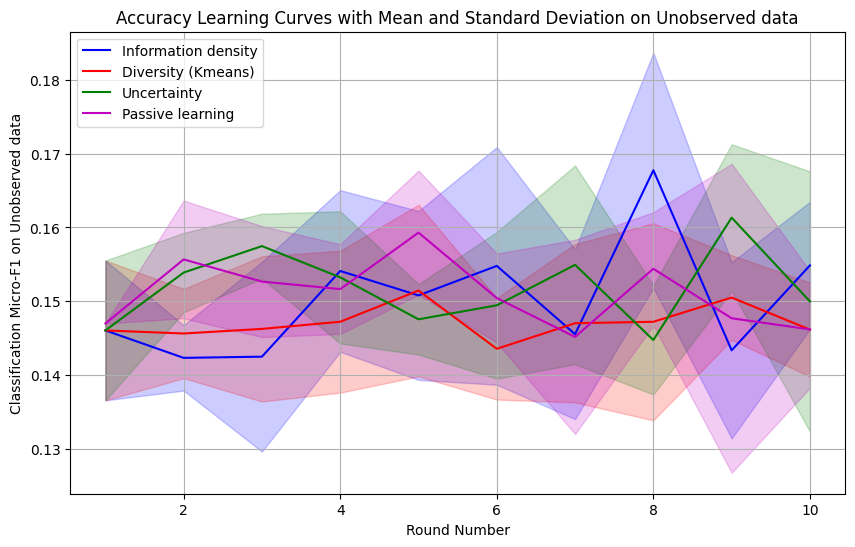

In [ ]:
rounds = range(1, len(info_micro_means) + 1)

plt.figure(figsize=(10, 6))

plt.plot(rounds, info_micro_means, 'b-', label='Information density')
plt.fill_between(rounds, info_micro_means - info_micro_stds, info_micro_means + info_micro_stds,
                color='b', alpha=0.2)

plt.plot(rounds, di_micro_means, 'r-', label='Diversity (Kmeans)')
plt.fill_between(rounds, di_micro_means - di_micro_stds, di_micro_means + di_micro_stds,
                color='r', alpha=0.2)

plt.plot(rounds, un_micro_means, 'g-', label='Uncertainty')
plt.fill_between(rounds, un_micro_means - un_micro_stds, un_micro_means + un_micro_stds,
                color='g', alpha=0.2)

plt.plot(rounds, pa_micro_means, 'm-', label='Passive learning')
plt.fill_between(rounds, pa_micro_means - pa_micro_stds, pa_micro_means + pa_micro_stds,
                color='m', alpha=0.2)

plt.xlabel('Round Number')
plt.ylabel('Classification Micro-F1 on Unobserved data')
plt.title('Accuracy Learning Curves with Mean and Standard Deviation on Unobserved data')
plt.legend()
plt.grid(True)
plt.show()

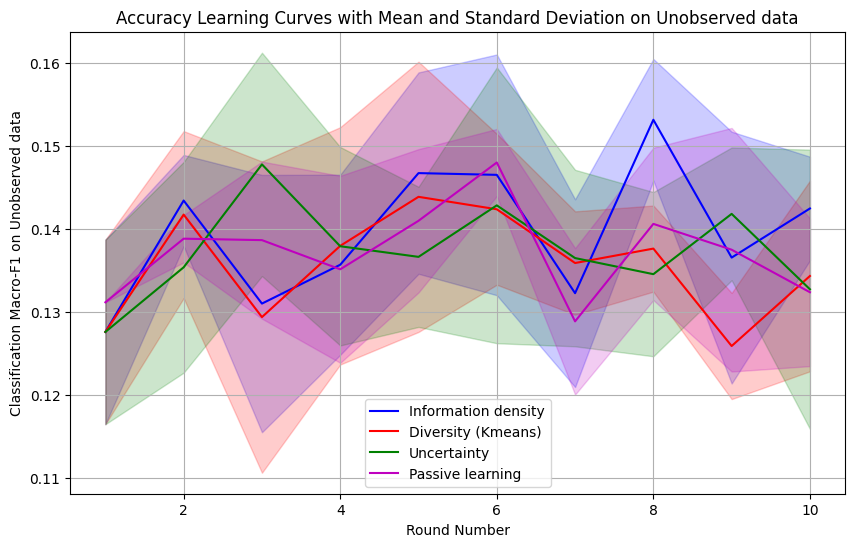

In [ ]:
rounds = range(1, len(info_macro_means) + 1)

plt.figure(figsize=(10, 6))

plt.plot(rounds, info_macro_means, 'b-', label='Information density')
plt.fill_between(rounds, info_macro_means - info_macro_stds, info_macro_means + info_macro_stds,
                color='b', alpha=0.2)

plt.plot(rounds, di_macro_means, 'r-', label='Diversity (Kmeans)')
plt.fill_between(rounds, di_macro_means - di_macro_stds, di_macro_means + di_macro_stds,
                color='r', alpha=0.2)

plt.plot(rounds, un_macro_means, 'g-', label='Uncertainty')
plt.fill_between(rounds, un_macro_means - un_macro_stds, un_macro_means + un_macro_stds,
                color='g', alpha=0.2)

plt.plot(rounds, pa_macro_means, 'm-', label='Passive learning')
plt.fill_between(rounds, pa_macro_means - pa_macro_stds, pa_macro_means + pa_macro_stds,
                color='m', alpha=0.2)


plt.xlabel('Round Number')
plt.ylabel('Classification Macro-F1 on Unobserved data')
plt.title('Accuracy Learning Curves with Mean and Standard Deviation on Unobserved data')
plt.legend()
plt.grid(True)
plt.show()

### Data size = 5000

#### Run experiments

In [ ]:
seeds = [36, 17, 88, 1234, 2025]

info5000_micro_results, info5000_macro_results, info5000_mse_results = run_simulations(
    data=data,
    seeds=seeds,
    data_size=5000,
    initial_size=2000,
    batch_size=100,
    n_iterations=30,
    method='information density'
)

===== Simulation 1 | Seed = 36 =====

--- Iter 1/30 | Labeled size = 2000 ---
Micro-F1: 0.4285 | Macro-F1: 0.3830 | MSE: 0.4862

--- Iter 2/30 | Labeled size = 2100 ---
Micro-F1: 0.2442 | Macro-F1: 0.1693 | MSE: 0.4378

--- Iter 3/30 | Labeled size = 2200 ---
Micro-F1: 0.3087 | Macro-F1: 0.2071 | MSE: 0.4082

--- Iter 4/30 | Labeled size = 2300 ---
Micro-F1: 0.3237 | Macro-F1: 0.2460 | MSE: 0.5350

--- Iter 5/30 | Labeled size = 2400 ---
Micro-F1: 0.4656 | Macro-F1: 0.3779 | MSE: 0.4066

--- Iter 6/30 | Labeled size = 2500 ---
Micro-F1: 0.4567 | Macro-F1: 0.4154 | MSE: 0.4772

--- Iter 7/30 | Labeled size = 2600 ---
Micro-F1: 0.3876 | Macro-F1: 0.2367 | MSE: 0.3567

--- Iter 8/30 | Labeled size = 2700 ---
Micro-F1: 0.3303 | Macro-F1: 0.2741 | MSE: 0.5119

--- Iter 9/30 | Labeled size = 2800 ---
Micro-F1: 0.3582 | Macro-F1: 0.2480 | MSE: 0.3725

--- Iter 10/30 | Labeled size = 2900 ---
Micro-F1: 0.4273 | Macro-F1: 0.3440 | MSE: 0.4846

--- Iter 11/30 | Labeled size = 3000 ---
Micro-F1: 

In [ ]:
seeds = [36, 17, 88, 1234, 2025]

un5000_micro_results, un5000_macro_results, un5000_mse_results = run_simulations(
    data=data,
    seeds=seeds,
    data_size=5000,
    initial_size=2000,
    batch_size=100,
    n_iterations=30,
    method='uncertainty sampling'
)

===== Simulation 1 | Seed = 36 =====

--- Iter 1/30 | Labeled size = 2000 ---
Micro-F1: 0.4285 | Macro-F1: 0.3830 | MSE: 0.4862

--- Iter 2/30 | Labeled size = 2100 ---
Micro-F1: 0.2461 | Macro-F1: 0.1704 | MSE: 0.4370

--- Iter 3/30 | Labeled size = 2200 ---
Micro-F1: 0.3144 | Macro-F1: 0.2180 | MSE: 0.4166

--- Iter 4/30 | Labeled size = 2300 ---
Micro-F1: 0.3192 | Macro-F1: 0.2551 | MSE: 0.5344

--- Iter 5/30 | Labeled size = 2400 ---
Micro-F1: 0.4391 | Macro-F1: 0.3405 | MSE: 0.3724

--- Iter 6/30 | Labeled size = 2500 ---
Micro-F1: 0.4374 | Macro-F1: 0.3991 | MSE: 0.5015

--- Iter 7/30 | Labeled size = 2600 ---
Micro-F1: 0.3711 | Macro-F1: 0.2383 | MSE: 0.3759

--- Iter 8/30 | Labeled size = 2700 ---
Micro-F1: 0.4394 | Macro-F1: 0.3891 | MSE: 0.4910

--- Iter 9/30 | Labeled size = 2800 ---
Micro-F1: 0.3995 | Macro-F1: 0.2713 | MSE: 0.3919

--- Iter 10/30 | Labeled size = 2900 ---
Micro-F1: 0.3449 | Macro-F1: 0.3001 | MSE: 0.4246

--- Iter 11/30 | Labeled size = 3000 ---
Micro-F1: 

In [ ]:
di5000_micro_results, di5000_macro_results, di5000_mse_results = run_simulations(
    data=data,
    seeds=seeds,
    data_size=5000,
    initial_size=2000,
    batch_size=100,
    n_iterations=30,
    method='diversity sampling'
)

In [ ]:
pa5000_micro_results, pa5000_macro_results, pa5000_mse_results = run_passive_simulations(
    data=data,
    seeds=seeds,
    data_size=5000,
    initial_size=2000,
    batch_size=100,
    n_iterations=30
)

#### Convert results

In [ ]:
di_micro = np.array(di5000_micro_results)
di_macro = np.array(di5000_macro_results)
di_mse = np.array(di5000_mse_results)

di_micro_means = np.mean(di_micro, axis=0)
di_micro_stds = np.std(di_micro, axis=0)
di_macro_means = np.mean(di_macro, axis=0)
di_macro_stds = np.std(di_macro, axis=0)
di_mse_means = np.mean(di_mse, axis=0)
di_mse_stds =  np.std(di_mse, axis=0)

In [ ]:
un_micro = np.array(un5000_micro_results)
un_macro = np.array(un5000_macro_results)
un_mse = np.array(un5000_mse_results)

un_micro_means = np.mean(un_micro, axis=0)
un_micro_stds = np.std(un_micro, axis=0)
un_macro_means = np.mean(un_macro, axis=0)
un_macro_stds = np.std(un_macro, axis=0)
un_mse_means = np.mean(un_mse, axis=0)
un_mse_stds = np.std(un_mse, axis=0)

In [ ]:
info_micro = np.array(info5000_micro_results)
info_macro = np.array(info5000_macro_results)
info_mse = np.array(info5000_mse_results)

info_micro_means = np.mean(info_micro, axis=0)
info_micro_stds = np.std(info_micro, axis=0)
info_macro_means = np.mean(info_macro, axis=0)
info_macro_stds = np.std(info_macro, axis=0)
info_mse_means = np.mean(info_mse, axis=0)
info_mse_stds = np.std(info_mse, axis=0)

In [ ]:
pa_micro = np.array(pa5000_micro_results)
pa_macro = np.array(pa5000_macro_results)
pa_mse = np.array(pa5000_mse_results)

pa_micro_means = np.mean(pa_micro, axis=0)
pa_micro_stds = np.std(pa_micro, axis=0)
pa_macro_means = np.mean(pa_macro, axis=0)
pa_macro_stds = np.std(pa_macro, axis=0)
pa_mse_means = np.mean(pa_mse, axis=0)
pa_mse_stds = np.std(pa_mse, axis=0)

#### Plot

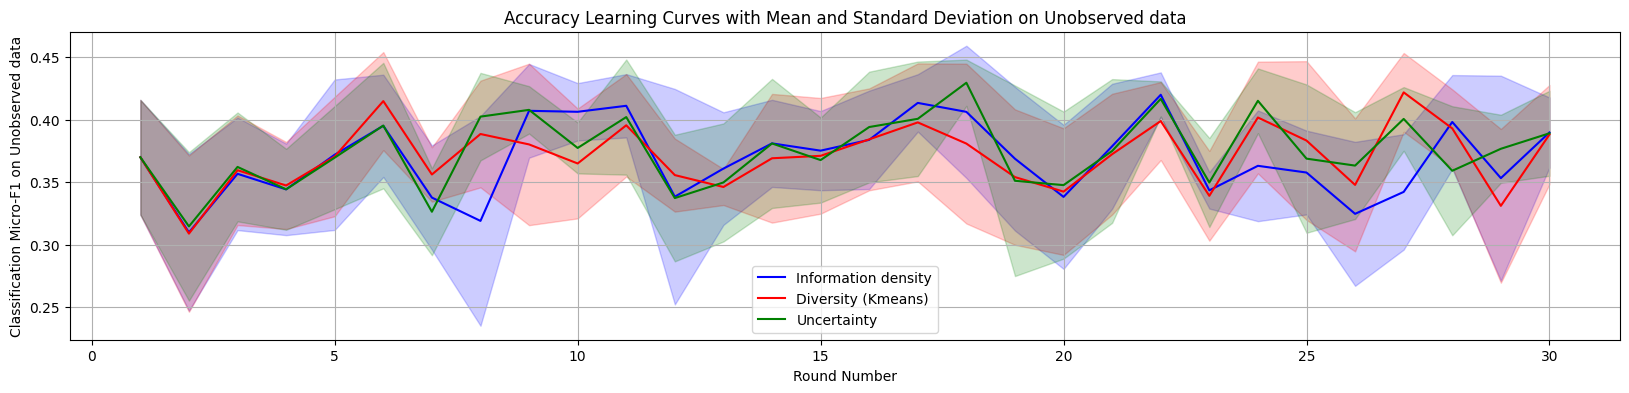

In [ ]:
rounds = range(1, len(info_micro_means) + 1)

plt.figure(figsize=(20, 4))

plt.plot(rounds, info_micro_means, 'b-', label='Information density')
plt.fill_between(rounds, info_micro_means - info_micro_stds, info_micro_means + info_micro_stds,
                color='b', alpha=0.2)

plt.plot(rounds, di_micro_means, 'r-', label='Diversity (Kmeans)')
plt.fill_between(rounds, di_micro_means - di_micro_stds, di_micro_means + di_micro_stds,
                color='r', alpha=0.2)

plt.plot(rounds, un_micro_means, 'g-', label='Uncertainty')
plt.fill_between(rounds, un_micro_means - un_micro_stds, un_micro_means + un_micro_stds,
                color='g', alpha=0.2)


plt.xlabel('Round Number')
plt.ylabel('Classification Micro-F1 on Unobserved data')
plt.title('Accuracy Learning Curves with Mean and Standard Deviation on Unobserved data')
plt.legend()
plt.grid(True)
plt.show()

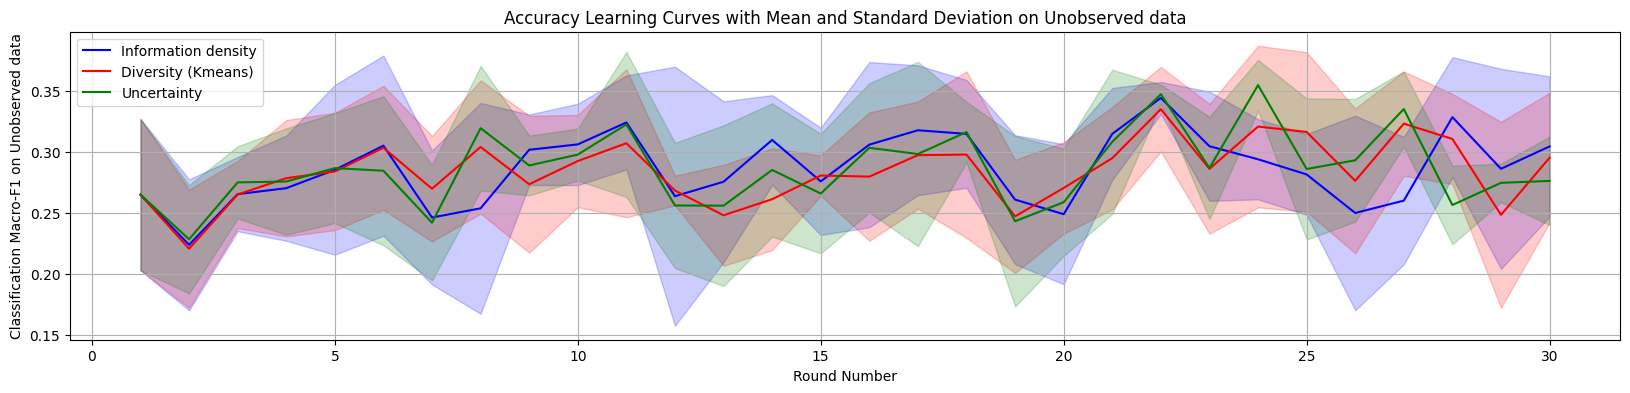

In [ ]:
rounds = range(1, len(info_macro_means) + 1)

plt.figure(figsize=(20, 4))

plt.plot(rounds, info_macro_means, 'b-', label='Information density')
plt.fill_between(rounds, info_macro_means - info_macro_stds, info_macro_means + info_macro_stds,
                color='b', alpha=0.2)

plt.plot(rounds, di_macro_means, 'r-', label='Diversity (Kmeans)')
plt.fill_between(rounds, di_macro_means - di_macro_stds, di_macro_means + di_macro_stds,
                color='r', alpha=0.2)

plt.plot(rounds, un_macro_means, 'g-', label='Uncertainty')
plt.fill_between(rounds, un_macro_means - un_macro_stds, un_macro_means + un_macro_stds,
                color='g', alpha=0.2)


plt.xlabel('Round Number')
plt.ylabel('Classification Macro-F1 on Unobserved data')
plt.title('Accuracy Learning Curves with Mean and Standard Deviation on Unobserved data')
plt.legend()
plt.grid(True)
plt.show()